### 01 — Data Understanding

#### Goal
Understand the RetailRocket event data before cleaning, transforming, or modelling it.

#### Questions
1. What does one row represent?
2. Which columns identify a visitor, product, event, and transaction?
3. How many events of each type exist?
4. Are there missing values or duplicate rows?

In [5]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

In [6]:
project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_directory = project_root / "data" / "raw" / "retailrocket"
events_path = data_directory / "events.csv"

reports_directory = project_root / "reports"
figures_directory = reports_directory / "figures"
figures_directory.mkdir(parents=True, exist_ok=True)

print(f"Project folder: {project_root}")
print(f"Events file exists: {events_path.exists()}")

Project folder: B:\Ab\projects\ecommerce-product-ds-case-study
Events file exists: True


In [7]:
events = pd.read_csv(
    events_path,
    dtype={
        "visitorid": "int64",
        "event": "category",
        "itemid": "int64",
        "transactionid": "Int64",
    },
)

events["event_time"] = pd.to_datetime(
    events["timestamp"],
    unit="ms",
    utc=True,
    errors="coerce",
)

events.head()

,timestamp,visitorid,event,itemid,transactionid,event_time
0,1433221332117,257597,view,355908,<NA>,2015-06-02 05:02:12.117000+00:00
1,1433224214164,992329,view,248676,<NA>,2015-06-02 05:50:14.164000+00:00
2,1433221999827,111016,view,318965,<NA>,2015-06-02 05:13:19.827000+00:00
3,1433221955914,483717,view,253185,<NA>,2015-06-02 05:12:35.914000+00:00
4,1433221337106,951259,view,367447,<NA>,2015-06-02 05:02:17.106000+00:00


In [8]:
print(f"Table shape: {events.shape}")
print("\nColumn types:")
print(events.dtypes)

schema_profile = pd.DataFrame(
    {
        "data_type": events.dtypes.astype(str),
        "missing_values": events.isna().sum(),
        "unique_values": events.nunique(dropna=True),
    }
)

schema_profile

Table shape: (2756101, 6)

Column types:
timestamp                      int64
visitorid                      int64
event                       category
itemid                         int64
transactionid                  Int64
event_time       datetime64[ms, UTC]
dtype: object


,data_type,missing_values,unique_values
timestamp,int64,0,2750455
visitorid,int64,0,1407580
event,category,0,3
itemid,int64,0,235061
transactionid,Int64,2733644,17672
event_time,"datetime64[ms, UTC]",0,2750455


In [9]:
overview = pd.Series(
    {
        "row_count": len(events),
        "column_count": len(events.columns),
        "first_event_utc": events["event_time"].min(),
        "last_event_utc": events["event_time"].max(),
        "unique_visitors": events["visitorid"].nunique(),
        "unique_items": events["itemid"].nunique(),
        "unique_transaction_ids": events["transactionid"].nunique(),
    },
    name="value",
).to_frame()

overview

,value
row_count,2756101
column_count,6
first_event_utc,2015-05-03 03:00:04.384000+00:00
last_event_utc,2015-09-18 02:59:47.788000+00:00
unique_visitors,1407580
unique_items,235061
unique_transaction_ids,17672


In [10]:
missing_values = (
    events.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

duplicate_rows = int(events.duplicated().sum())

print(f"Exact duplicate rows: {duplicate_rows:,}")
missing_values

Exact duplicate rows: 460


,missing_values
timestamp,0
visitorid,0
event,0
itemid,0
transactionid,2733644
event_time,0


In [11]:
is_transaction = events["event"].eq("transaction")

transactionid_checks = pd.Series(
    {
        "transaction_rows": int(is_transaction.sum()),
        "transaction_rows_missing_transactionid": int(
            events.loc[is_transaction, "transactionid"].isna().sum()
        ),
        "non_transaction_rows_with_transactionid": int(
            events.loc[~is_transaction, "transactionid"].notna().sum()
        ),
        "unique_transaction_ids": int(events["transactionid"].nunique()),
    },
    name="value",
).to_frame()

transactionid_checks

,value
transaction_rows,22457
transaction_rows_missing_transactionid,0
non_transaction_rows_with_transactionid,0
unique_transaction_ids,17672


In [12]:
event_summary = (
    events["event"]
    .value_counts(dropna=False)
    .rename_axis("event")
    .reset_index(name="event_count")
)

event_summary["event_share_pct"] = (
    event_summary["event_count"] / len(events) * 100
).round(2)

event_summary

,event,event_count,event_share_pct
0,view,2664312,96.67
1,addtocart,69332,2.52
2,transaction,22457,0.81


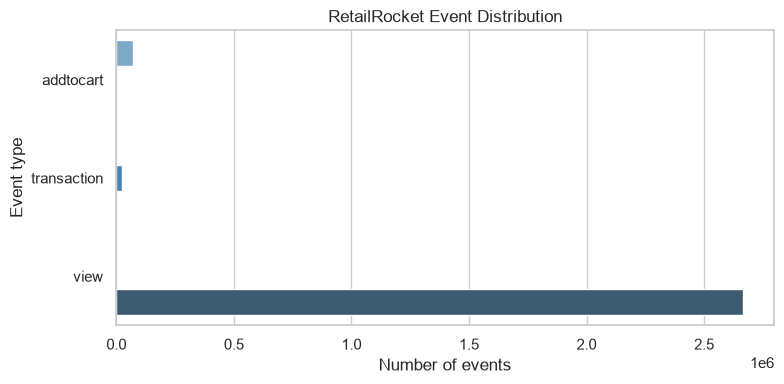

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=event_summary,
    x="event_count",
    y="event",
    hue="event",
    legend=False,
    palette="Blues_d",
    ax=ax,
)

ax.set_title("RetailRocket Event Distribution")
ax.set_xlabel("Number of events")
ax.set_ylabel("Event type")

fig.tight_layout()
fig.savefig(
    figures_directory / "phase_1_event_distribution.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [14]:
daily_events = (
    events.groupby(events["event_time"].dt.floor("D"), observed=True)
    .size()
    .rename("event_count")
    .reset_index()
)

daily_events.head()

,event_time,event_count
0,2015-05-03 00:00:00+00:00,13683
1,2015-05-04 00:00:00+00:00,19414
2,2015-05-05 00:00:00+00:00,23015
3,2015-05-06 00:00:00+00:00,23920
4,2015-05-07 00:00:00+00:00,23164


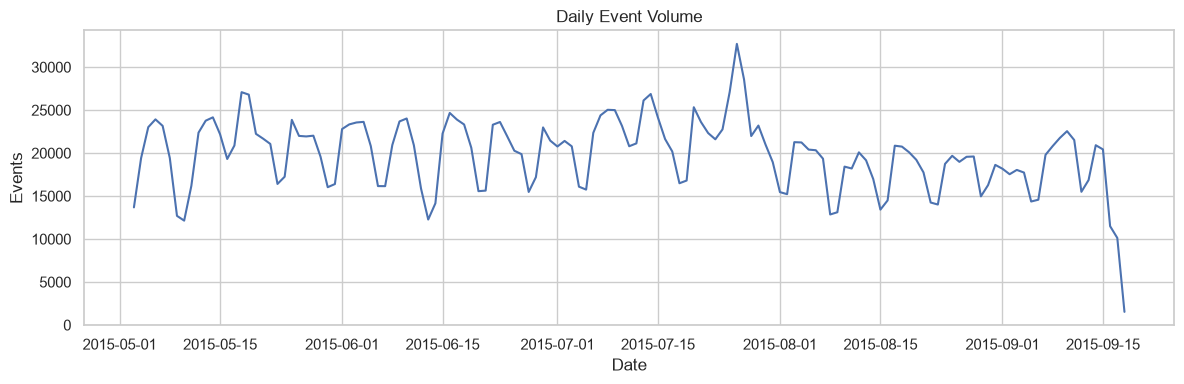

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(
    data=daily_events,
    x="event_time",
    y="event_count",
    ax=ax,
)

ax.set_title("Daily Event Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Events")

fig.tight_layout()
fig.savefig(
    figures_directory / "phase_1_daily_event_volume.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [16]:
visitor_event_counts = (
    events.groupby("visitorid", sort=False)
    .size()
    .rename("event_count")
)

visitor_activity_summary = visitor_event_counts.quantile(
    [0, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999, 1]
).rename_axis("quantile").to_frame("events_per_visitor")

visitor_activity_summary

,events_per_visitor
quantile,
0.000,1.0
0.250,1.0
0.500,1.0
0.750,2.0
0.900,3.0
0.990,13.0
0.999,47.0
1.000,7757.0


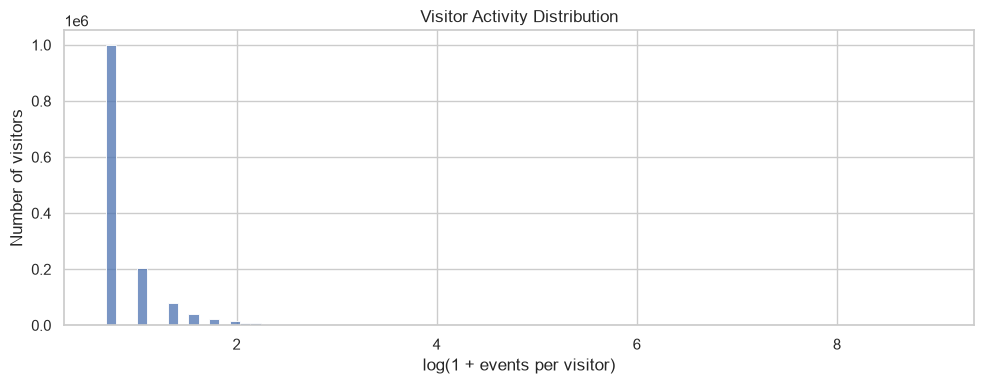

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.histplot(
    np.log1p(visitor_event_counts),
    bins=80,
    ax=ax,
)

ax.set_title("Visitor Activity Distribution")
ax.set_xlabel("log(1 + events per visitor)")
ax.set_ylabel("Number of visitors")

fig.tight_layout()
fig.savefig(
    figures_directory / "phase_1_visitor_activity_distribution.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [18]:
extreme_activity_threshold = visitor_event_counts.quantile(0.999)
extreme_activity_visitors = visitor_event_counts[
    visitor_event_counts >= extreme_activity_threshold
]

extreme_activity_summary = pd.DataFrame(
    {
        "metric": [
            "99.9th percentile of events per visitor",
            "visitors at or above threshold",
            "share of visitors at or above threshold (%)",
            "maximum events for one visitor",
        ],
        "value": [
            round(extreme_activity_threshold, 2),
            len(extreme_activity_visitors),
            round(len(extreme_activity_visitors) / len(visitor_event_counts) * 100, 3),
            int(visitor_event_counts.max()),
        ],
    }
)

extreme_activity_summary

,metric,value
0,99.9th percentile of events per visitor,47.0
1,visitors at or above threshold,1413.0
2,share of visitors at or above threshold (%),0.1
3,maximum events for one visitor,7757.0


## Extreme-activity note

Visitors above the 99.9th percentile are flagged only for sensitivity analysis.
They are not confirmed bots because the dataset has no bot labels.
No records are removed in Phase 1.

#### Create a DuckDB View
DuckDB lets us work in SQL without creating a database server.

In [19]:
connection = duckdb.connect(database=":memory:")

events_path_sql = events_path.as_posix().replace("'", "''")

connection.execute(
    f"""
    CREATE OR REPLACE VIEW events_raw AS
    SELECT
        CAST(timestamp AS BIGINT) AS timestamp_ms,
        CAST(visitorid AS BIGINT) AS visitorid,
        CAST(event AS VARCHAR) AS event,
        CAST(itemid AS BIGINT) AS itemid,
        CAST(transactionid AS BIGINT) AS transactionid
    FROM read_csv_auto('{events_path_sql}', header = true);
    """
)

connection.sql(
    """
    SELECT
        event,
        COUNT(*) AS event_count
    FROM events_raw
    GROUP BY event
    ORDER BY event_count DESC;
    """
).df()

,event,event_count
0,view,2664312
1,addtocart,69332
2,transaction,22457


#### Sessionization Function
A session is a sequence of activity separated by less than 30 minutes of inactivity. This is an assumption, not a fact recorded in the data.

In [20]:
def build_session_metrics(inactivity_minutes: int) -> pd.DataFrame:
    inactivity_milliseconds = inactivity_minutes * 60 * 1000

    query = f"""
    WITH ordered_events AS (
        SELECT
            visitorid,
            timestamp_ms,
            event,
            itemid,
            transactionid,
            CASE
                WHEN LAG(timestamp_ms) OVER (
                    PARTITION BY visitorid
                    ORDER BY timestamp_ms, itemid, event
                ) IS NULL THEN 1
                WHEN timestamp_ms - LAG(timestamp_ms) OVER (
                    PARTITION BY visitorid
                    ORDER BY timestamp_ms, itemid, event
                ) > {inactivity_milliseconds} THEN 1
                ELSE 0
            END AS starts_new_session
        FROM events_raw
    ),

    labelled_events AS (
        SELECT
            *,
            SUM(starts_new_session) OVER (
                PARTITION BY visitorid
                ORDER BY timestamp_ms, itemid, event
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS session_number
        FROM ordered_events
    ),

    session_level AS (
        SELECT
            visitorid,
            session_number,
            COUNT(*) AS event_count,
            COUNT_IF(event = 'view') AS view_count,
            COUNT_IF(event = 'addtocart') AS cart_count,
            COUNT_IF(event = 'transaction') AS transaction_count
        FROM labelled_events
        GROUP BY visitorid, session_number
    )

    SELECT
        COUNT(*) AS session_count,
        COUNT_IF(view_count > 0) AS sessions_with_view,
        COUNT_IF(cart_count > 0) AS sessions_with_cart,
        COUNT_IF(transaction_count > 0) AS sessions_with_transaction,
        ROUND(
            100.0 * COUNT_IF(cart_count > 0)
            / NULLIF(COUNT_IF(view_count > 0), 0),
            3
        ) AS view_to_cart_rate_pct,
        ROUND(
            100.0 * COUNT_IF(transaction_count > 0)
            / NULLIF(COUNT_IF(view_count > 0), 0),
            3
        ) AS view_to_transaction_rate_pct
    FROM session_level;
    """

    return connection.execute(query).df()

Check the Session Assumption

In [21]:
session_sensitivity = pd.concat(
    [
        build_session_metrics(minutes).assign(
            inactivity_minutes=minutes
        )
        for minutes in [15, 30, 60]
    ],
    ignore_index=True,
)

session_sensitivity

,session_count,sessions_with_view,sessions_with_cart,sessions_with_transaction,view_to_cart_rate_pct,view_to_transaction_rate_pct,inactivity_minutes
0,1809161,1801929.0,46006.0,15449.0,2.553,0.857,15
1,1761675,1755781.0,43924.0,14297.0,2.502,0.814,30
2,1726714,1721538.0,42539.0,13446.0,2.471,0.781,60


In [22]:
default_session_metrics = session_sensitivity.loc[
    session_sensitivity["inactivity_minutes"].eq(30)
].iloc[0]

session_event_reach = pd.DataFrame(
    {
        "stage": [
            "Sessions with a view",
            "Sessions with an add-to-cart",
            "Sessions with a transaction",
        ],
        "session_count": [
            int(default_session_metrics["sessions_with_view"]),
            int(default_session_metrics["sessions_with_cart"]),
            int(default_session_metrics["sessions_with_transaction"]),
        ],
    }
)

session_event_reach

,stage,session_count
0,Sessions with a view,1755781
1,Sessions with an add-to-cart,43924
2,Sessions with a transaction,14297


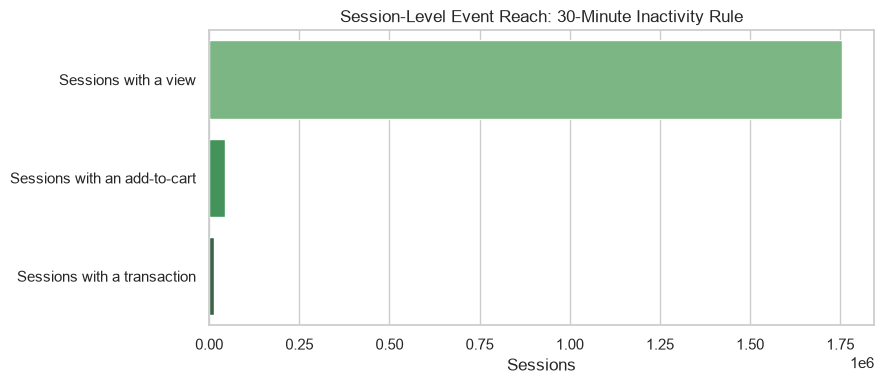

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.barplot(
    data=session_event_reach,
    x="session_count",
    y="stage",
    hue="stage",
    legend=False,
    palette="Greens_d",
    ax=ax,
)

ax.set_title("Session-Level Event Reach: 30-Minute Inactivity Rule")
ax.set_xlabel("Sessions")
ax.set_ylabel("")

fig.tight_layout()
fig.savefig(
    figures_directory / "phase_1_session_event_reach.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [24]:
quality_metrics = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "unique_visitors",
            "unique_items",
            "unique_transaction_ids",
            "first_event_utc",
            "last_event_utc",
            "duplicate_rows",
            "invalid_event_timestamps",
            "transaction_rows_missing_transactionid",
            "non_transaction_rows_with_transactionid",
        ],
        "value": [
            len(events),
            events["visitorid"].nunique(),
            events["itemid"].nunique(),
            events["transactionid"].nunique(),
            events["event_time"].min(),
            events["event_time"].max(),
            duplicate_rows,
            events["event_time"].isna().sum(),
            transactionid_checks.loc[
                "transaction_rows_missing_transactionid", "value"
            ],
            transactionid_checks.loc[
                "non_transaction_rows_with_transactionid", "value"
            ],
        ],
    }
)

quality_metrics.to_csv(
    reports_directory / "phase_1_data_quality_metrics.csv",
    index=False,
)

event_summary.to_csv(
    reports_directory / "phase_1_event_distribution.csv",
    index=False,
)

session_sensitivity.to_csv(
    reports_directory / "phase_1_sessionization_sensitivity.csv",
    index=False,
)

print("Phase 1 metrics and figures saved in reports/.")

Phase 1 metrics and figures saved in reports/.


# Phase 1 Summary

## Dataset
The event log contains 2,756,101 events from 2015-05-03 to 2015-09-18, involving 1,407,580 visitors and 235,061 items.

## Event mix
Views account for 96.67% of events, add-to-cart events account for 2.52%, and transaction events account for 0.81%.

## Data quality
There are 460 exact duplicate rows and no invalid timestamps. All 22,457 transaction rows have a transaction ID, and no non-transaction event has one.

## Activity concentration
Visitor activity is highly concentrated: the median visitor has one event, the 99.9th percentile is 47 events, and the maximum is 7,757 events. The most active 0.1% of visitors are flagged only for sensitivity analysis, not treated as confirmed bots.

## Sessionization
Using 15-, 30-, and 60-minute inactivity thresholds produces transaction event reach between 0.781% and 0.857% of sessions containing a view. The overall pattern is stable. A 30-minute inactivity threshold is used as the primary session definition.

## Limitation
These are observed behavioural patterns. They do not establish that any product feature caused users to purchase.